In [1]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# 전처리된 데이터 불러오기
df = pd.read_csv("data/player_preprocessed.csv")
print(f"✅ 불러온 전처리 데이터 shape: {df.shape}")


✅ 불러온 전처리 데이터 shape: (100, 291)


In [2]:
# 클러스터 수 설정
n_clusters = 5

# KMeans 모델 학습 및 예측
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
clusters = kmeans.fit_predict(df)

# 클러스터 결과 추가
df['cluster'] = clusters
print("🎯 클러스터링 완료. cluster 컬럼 추가됨.")
df.head()


🎯 클러스터링 완료. cluster 컬럼 추가됨.


C:\Users\wgdcw\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,gameDuration,PlayerScore0,PlayerScore1,PlayerScore10,PlayerScore11,PlayerScore2,PlayerScore3,PlayerScore4,PlayerScore5,PlayerScore6,...,challenges_soloTurretsLategame,challenges_controlWardTimeCoverageInRiverOrEnemyHalf,challenges_highestChampionDamage,challenges_fasterSupportQuestCompletion,challenges_highestWardKills,challenges_baronBuffGoldAdvantageOverThreshold,challenges_earliestBaron,challenges_teleportTakedowns,challenges_thirdInhibitorDestroyedTime,cluster
0,-0.422644,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.398673,-1.043100,-0.333333,-0.274352,-0.386556,-0.333333,-0.576257,-0.175863,-0.229416,2
1,-0.422644,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.262465,-1.043100,-0.333333,-0.274352,-0.386556,-0.333333,-0.576257,-0.175863,-0.229416,4
2,-0.422644,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.398673,0.593128,-0.333333,-0.274352,-0.386556,-0.333333,-0.576257,-0.175863,-0.229416,2
3,-0.422644,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.262465,0.150071,3.000000,-0.274352,-0.386556,-0.333333,-0.576257,-0.175863,-0.229416,2
4,-0.422644,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.398673,1.057954,-0.333333,-0.274352,-0.386556,-0.333333,-0.576257,-0.175863,-0.229416,1


C:\Users\wgdcw\AppData\Local\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


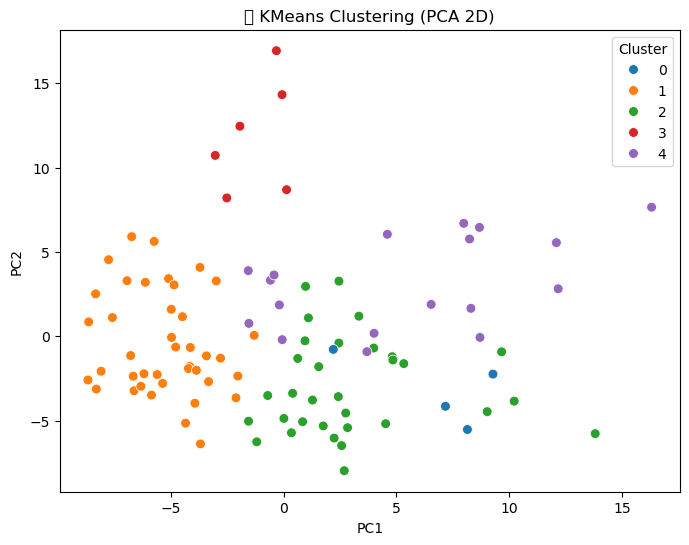

In [3]:
# PCA로 2차원 축소
pca = PCA(n_components=2)
pca_result = pca.fit_transform(df.drop(columns=['cluster']))

# 시각화용 DataFrame
plot_df = pd.DataFrame(pca_result, columns=['PC1', 'PC2'])
plot_df['cluster'] = df['cluster']

# 시각화
plt.figure(figsize=(8,6))
sns.scatterplot(data=plot_df, x='PC1', y='PC2', hue='cluster', palette='tab10', s=50)
plt.title("🎯 KMeans Clustering (PCA 2D)")
plt.legend(title='Cluster')
plt.show()


In [7]:
df.to_csv("data/player_clustered.csv", index=False, encoding='utf-8-sig')
print("📁 클러스터링 결과 저장 완료: data/player_clustered.csv")


📁 클러스터링 결과 저장 완료: data/player_clustered.csv
